# **Do Spotify audio features capture a meaningful underlying structure of music, and how does this structure compare to genre labels and popularity?**

*names*

# **INTRODUCTION**

objectives and stuff

## **OVERALL ML STRATEGY**

This project is designed as a multi-perspective machine learning study rather than a single predictive task. The Spotify dataset is treated as a structured environment in which different modeling approaches can reveal complementary aspects of music.

The central idea is that the same dataset can support multiple legitimate machine learning questions, each offering a different interpretation of musical structure. In some cases, we aim to predict labels from features, such as genre or popularity. In other cases, we remove labels entirely and explore how songs organize themselves naturally. These approaches are not competing, but complementary views of the same data.

The project is therefore structured around four main analytical perspectives:

Text-based modeling, which evaluates whether textual information (track and playlist names) captures meaningful musical patterns
Popularity prediction, which examines whether musical features relate to success
Clustering, which investigates whether latent musical groupings emerge without labels
Dimensionality reduction and visualization, which provide a geometric representation of the feature space

Each perspective addresses a distinct research question while contributing to a broader understanding of how music can be represented.

At a high level, the project follows a two-stage workflow:

1. Shared Data Preparation

The dataset is first loaded, inspected, and cleaned to produce a consistent base dataset. This includes handling missing values, removing duplicates where necessary, and selecting relevant columns. The result is a clean dataset (df_clean) used across all analyses.

2. Task-Specific Modeling Pipelines

Each analytical block defines its own pipeline depending on the modeling objective. While all blocks start from the same cleaned dataset, the preprocessing steps and modeling choices differ based on the type of task being addressed.

- Text-Based Modeling (NLP + Neural Networks)
A textual representation is created by combining track and playlist names. The text is transformed into numerical features using TF-IDF. The dataset is then split into training and test sets, and classification models (Logistic Regression and a Multilayer Perceptron) are trained to evaluate whether textual information captures meaningful musical patterns.
- Popularity Prediction
The target variable is defined as a categorical version of track popularity (e.g., low, medium, high). Separate feature sets are constructed using audio features, textual features, and their combination. Numerical features are scaled where appropriate. The dataset is split, and multiple models (Logistic Regression, Random Forest, Gradient Boosting) are trained and compared to assess how well popularity can be predicted from different types of information.
- Clustering (Unsupervised Learning)
Only numerical audio features are used. These features are scaled to ensure comparability. Dimensionality reduction (PCA) may be applied before clustering. K-Means (and optionally GMM) is used to identify latent groupings in the data without using labels. Cluster quality is evaluated using metrics such as silhouette score, and clusters are later compared to genre and popularity.
- Dimensionality Reduction and Visualization
PCA (and optionally UMAP) is applied to project high-dimensional feature spaces into two dimensions. These projections are visualized by coloring points according to genre, popularity, or cluster assignments. This step provides an interpretable geometric view of the relationships uncovered in the previous analyses.

This design improves interpretability and analytical depth. If the project relied on a single target, conclusions would remain limited. By combining classification, prediction, clustering, and visualization, we can compare what aspects of music are easily captured by the data and what are not.

For example, if genre can be predicted accurately but popularity cannot, this suggests that musical structure is well represented in the features, while success depends on external factors beyond the dataset. Similarly, if clustering reveals patterns that do not align with genre labels, this highlights the limitations of predefined categories in representing musical reality.

In summary, the project uses a shared cleaned dataset and multiple machine learning perspectives to provide a richer and more comprehensive analysis of music.

# **1. DATA PREPARATION**

The first step is to load the dataset and understand what we're actually working with before building any models. This means checking the structure of the data, the types of variables, and what each column represents.

The dataset contains different kinds of information. Some columns are identifiers (like track or playlist IDs), which are not useful for prediction. Others are descriptive text, such as track names or artists, which may carry some contextual information. We also have playlist-level labels like genre and subgenre, the popularity score, and a set of numerical audio features (such as danceability, energy, tempo, etc.), which describe the music itself.

This distinction is important for the project. Audio features represent intrinsic properties of the songs, while text and playlist labels reflect external or contextual information. Since our goal is to compare different representations of music, separating these groups early helps us stay consistent in how we use them later.

For the supervised part of the project, we use track popularity as the target variable. It is originally a numerical value between 0 and 100, but instead of predicting the exact value, we convert it into three categories: low, medium, and high popularity. This makes the problem easier to interpret and better suited for classification models. The categories are defined using quantiles to ensure a balanced distribution of classes.

During exploration, we also look at the distribution of the main variables. For numerical features, we check ranges and general shape (for example, whether values are skewed or concentrated). For categorical variables like genre, we look at how balanced the classes are. We also inspect the distribution of popularity. These checks are important because imbalance or overlapping distributions can affect our models' performance and our interpretation of the results.

One important observation is that **the same track can appear multiple times across different playlists**. This means the dataset is playlist-based rather than track-based, so the observations are not fully independent. We decided not to remove the duplicates, because they represent different contexts in each playlist, and if we deleted them, we would be losing some playlist/context information. But we also have to acknowledge that this may introduce bias and it needs to be considered during interpretation.

## 1.1 FIRST LOOK AT THE DATA

In [4]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DISPLAY AND PLOT SETTINGS

pd.set_option("display.max_columns", None) # Display settings
pd.set_option("display.width", 120)
sns.set(style="whitegrid") # Plot settings

In [5]:
# LOAD DATASET

df = pd.read_csv("spotify_songs.csv")
print(f"Shape: {df.shape}") # Rows = samples ; Columns = features ; 33k observations, 23 features

Shape: (32833, 23)


The dataset contains 32833 observations and 23 features. This size is sufficient for both supervised and unsupervised learning tasks. We should have more than enough data to find significant patterns.

In [6]:
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes) # Numeric vs categorical variables

df.info()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052



Column names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Data types:


track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

A quick inspection of the dataset confirms that each row corresponds to a track within a playlist. The data includes a mix of identifiers, textual information, and numerical audio features, which will need to be handled differently during preprocessing.

## 1.2 DESCRIPTIVE STATISTICS

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

display(df[numerical_cols].describe().T)
display(df[categorical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996


,count,unique,top,freq
track_id,32833,28356,7BKLCZ1jbUBVqRi2FVlTVw,10
track_name,32828,23449,Poison,22
track_artist,32828,10692,Martin Garrix,161
track_album_id,32833,22545,5L1xcowSxwzFUSJzvyMp48,42
track_album_name,32828,19743,Greatest Hits,139
track_album_release_date,32833,4530,2020-01-10,270
playlist_name,32833,449,Indie Poptimism,308
playlist_id,32833,471,4JkkvMpVl4lSioqQjeAL0q,247
playlist_genre,32833,6,edm,6043
playlist_subgenre,32833,24,progressive electro house,1809


The numerical summary shows that audio features are generally well-scaled within expected ranges, although some variables (such as tempo and duration) have wider ranges. Feature scaling will be important for certain models later on.

## 1.3 CLASS DISTRIBUTION (GENRE AND SUBGENRE)

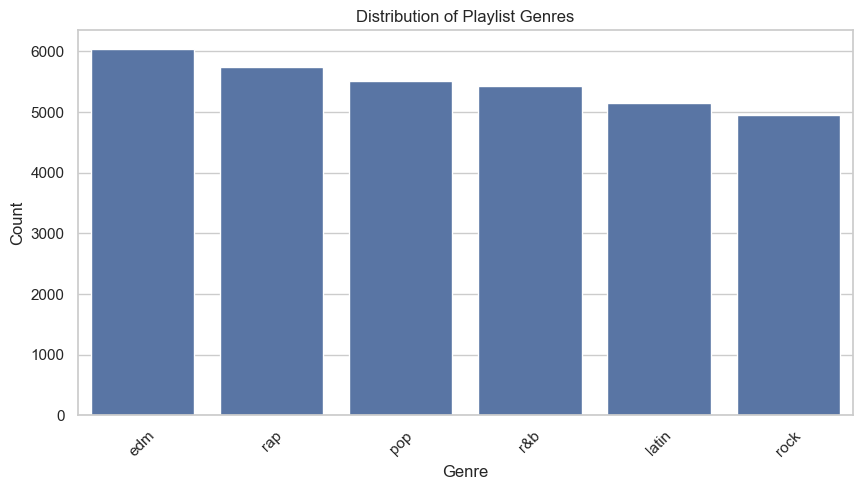

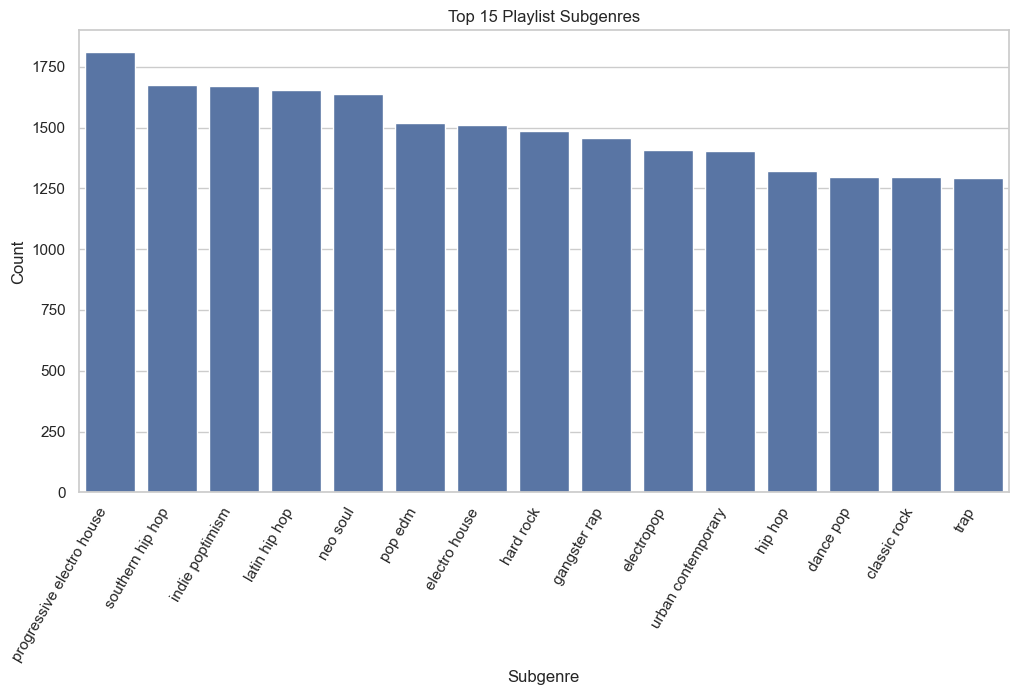

In [8]:
if "playlist_genre" in df.columns:
    plt.figure(figsize=(10, 5))
    genre_counts = df["playlist_genre"].value_counts()
    sns.barplot(x=genre_counts.index, y=genre_counts.values)
    plt.title("Distribution of Playlist Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

if "playlist_subgenre" in df.columns:
    plt.figure(figsize=(12, 6))
    subgenre_counts = df["playlist_subgenre"].value_counts().head(15)
    sns.barplot(x=subgenre_counts.index, y=subgenre_counts.values)
    plt.title("Top 15 Playlist Subgenres")
    plt.xlabel("Subgenre")
    plt.ylabel("Count")
    plt.xticks(rotation=60, ha="right")
    plt.show()

The distribution of genres and subgenres is not perfectly balanced, with some categories appearing much more frequently than others. This imbalance can affect classification performance and reinforces the need for appropriate evaluation metrics such as macro F1.

## 1.4 POPULARITY DISTRIBUTION

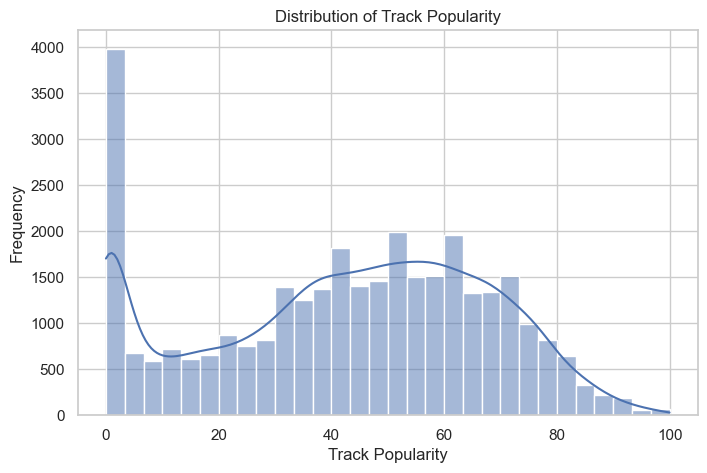

In [9]:
if "track_popularity" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["track_popularity"], bins=30, kde=True)
    plt.title("Distribution of Track Popularity")
    plt.xlabel("Track Popularity")
    plt.ylabel("Frequency")
    plt.show()

Track popularity is spread across the full range from 0 to 100, without extreme concentration in a single region. This supports transforming it into balanced categories for classification using quantiles rather than treating it as a regression problem.

## 1.5 AUDIO FEATURES DISTRIBUTION

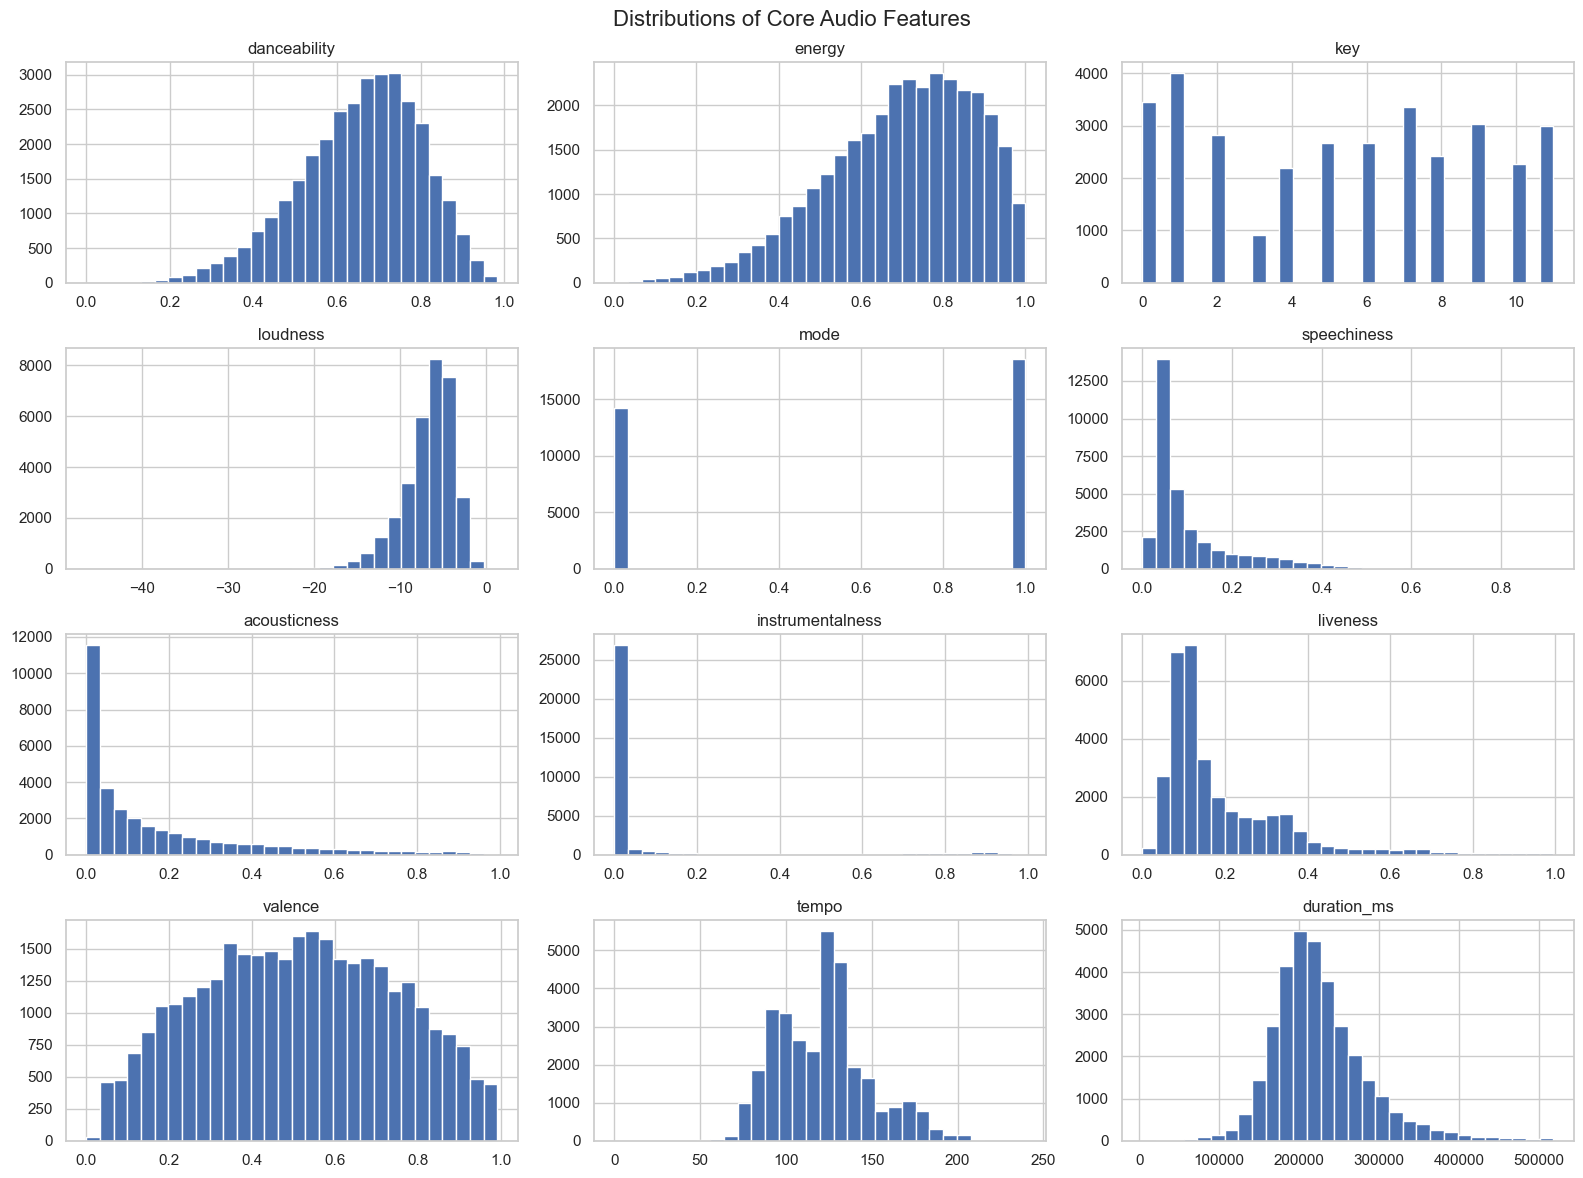

In [10]:
audio_features = [
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms"]

audio_features = [col for col in audio_features if col in df.columns]

df[audio_features].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions of Core Audio Features", fontsize=16)
plt.tight_layout()
plt.show()

The distributions of audio features vary across variables, with some showing skewness or concentration around specific values. Different features may carry different levels of information and may require scaling or transformation.

## 1.6 CORRELATION HEATMAP

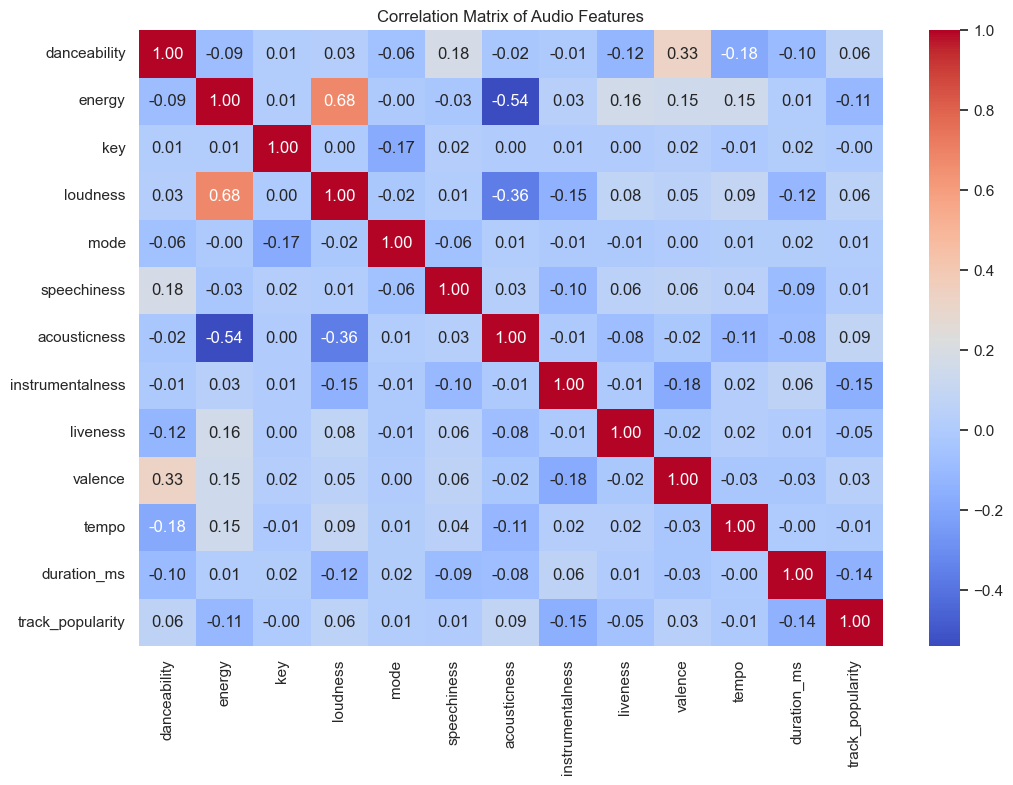

In [11]:
plt.figure(figsize=(12, 8))
corr_matrix = df[audio_features + (["track_popularity"] if "track_popularity" in df.columns else [])].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Audio Features")
plt.show()

The correlation analysis shows generally weak relationships between individual audio features and track popularity. This means that popularity may not be strongly explained by audio features alone, which aligns with the idea that external factors also play a role.

Some artists appear much more frequently than others; there may be potential bias in the dataset. Moreover, repeated tracks confirm that the same song can appear in multiple contexts, as mentioned earlier.

## 1.7 ARTIST AND TRACK FREQUENCY

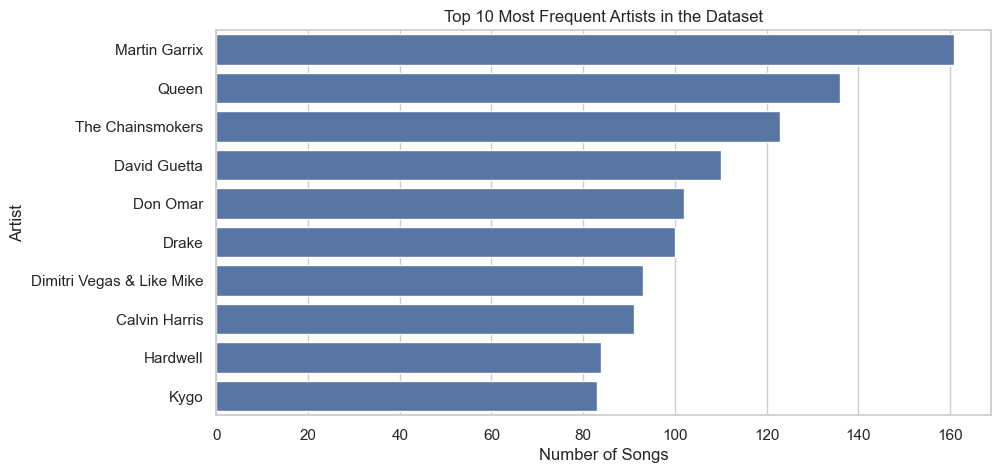


Number of tracks appearing more than once: 3166


track_id
7BKLCZ1jbUBVqRi2FVlTVw    10
14sOS5L36385FJ3OL8hew4     9
3eekarcy7kvN4yt5ZFzltW     9
6oJ6le65B3SEqPwMRNXWjY     8
6wo37KVqFJhtuxPTpLCcfe     8
0qaWEvPkts34WF68r8Dzx9     8
2Fxmhks0bxGSBdJ92vM42m     8
2tnVG71enUj33Ic2nFN6kZ     8
0rIAC4PXANcKmitJfoqmVm     8
3ZCTVFBt2Brf31RLEnCkWJ     8
Name: count, dtype: int64

In [12]:
# artists

if "track_artist" in df.columns:
    top_artists = df["track_artist"].value_counts().head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_artists.values, y=top_artists.index)
    plt.title("Top 10 Most Frequent Artists in the Dataset")
    plt.xlabel("Number of Songs")
    plt.ylabel("Artist")
    plt.show()

# REPEATED TRACKS

if "track_id" in df.columns:
    repeated_track_counts = df["track_id"].value_counts() # If we count by track name instead of ID, we also get different counts because different songs have the same names
    repeated_tracks = repeated_track_counts[repeated_track_counts > 1]
    print(f"\nNumber of tracks appearing more than once: {repeated_tracks.shape[0]}")
    display(repeated_tracks.head(10))

## 1.8 HANDLING MISSING AND DUPLICATE VALUES

We begin the data preparation process by handling missing values. Since the dataset contains only a very small number of missing observations, we choose to remove these rows entirely. Given the size of the dataset, this has a negligible impact on the analysis while ensuring data consistency and avoiding the need for imputation.

In [13]:
# Count missing values per column
missing_counts = df.isnull().sum()

# Show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]

print("Missing values per column:")
print(missing_counts)

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Total missing values: 15


In [14]:
# Handle missing values by dropping rows with any missing entries
df_clean = df.dropna()

print("Original shape:", df.shape)
print("Shape after removing missing values:", df_clean.shape)

# Verify no missing values remain
print("Remaining missing values:", df_clean.isnull().sum().sum())

Original shape: (32833, 23)
Shape after removing missing values: (32828, 23)
Remaining missing values: 0


In [15]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


The next step would be to remove full duplicates but since we already found that there are none, and we don't intend to remove the songs that are the same but are in different playlists, we will skip this part.

After cleaning the dataset, we select only the relevant columns required for the analysis. This includes textual information, target variables, and core audio features. Removing unnecessary columns simplifies the dataset and ensures that subsequent modeling steps remain focused and efficient

## 1.9 COLUMN DEFINITION

In [16]:
# Define relevant columns for the project
columns_to_keep = [
    "track_name",
    "playlist_name",
    "playlist_genre",
    "playlist_subgenre",
    "track_popularity",
    "track_artist",
    "track_album_name",
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]

# Keep only selected columns
df_clean = df_clean[columns_to_keep]

print("Final dataset shape:", df_clean.shape)
display(df_clean.head())

Final dataset shape: (32828, 19)


,track_name,playlist_name,playlist_genre,playlist_subgenre,track_popularity,track_artist,track_album_name,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Pop Remix,pop,dance pop,66,Ed Sheeran,I Don't Care (with Justin Bieber) [Loud Luxury...,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,Memories - Dillon Francis Remix,Pop Remix,pop,dance pop,67,Maroon 5,Memories (Dillon Francis Remix),0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,All the Time - Don Diablo Remix,Pop Remix,pop,dance pop,70,Zara Larsson,All the Time (Don Diablo Remix),0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,Call You Mine - Keanu Silva Remix,Pop Remix,pop,dance pop,60,The Chainsmokers,Call You Mine - The Remixes,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,Someone You Loved - Future Humans Remix,Pop Remix,pop,dance pop,69,Lewis Capaldi,Someone You Loved (Future Humans Remix),0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


---

# **2. TASK-SPECIFIC PIPELINES**

## **A. TEXT-BASED MODELING**

## A.1 PROBLEM DEFINITION AND TARGET VARIABLES

We formulate this task as a supervised classification problem in which textual information is used to predict a target variable. The input consists of textual representations derived from track and playlist names, while the target corresponds to a categorical variable (e.g., genre or popularity class).

The objective is not only to achieve predictive performance, but to evaluate whether textual features contain meaningful information about musical structure. By comparing simple and more complex models, we assess the nature and complexity of the signal contained in text.

Genre is used as a proxy for underlying musical structure, allowing us to test whether textual features capture meaningful patterns in music. Unlike popularity, which is influenced by many external factors, genre provides a cleaner and more direct signal tied to the characteristics of the song itself. This step helps validate that text contains useful information before analyzing whether it can explain more complex outcomes such as popularity.

The difference between using genre and popularity lies in the target definition: genre is already categorical, while popularity must be discretized into classes before modeling. The rest of the pipeline remains unchanged, allowing consistent comparison across tasks.

In the text-based pipeline, TF-IDF serves as the encoding step by converting text into numerical features. Feature scaling is not required, as TF-IDF already normalizes feature values. Additional encoding or scaling techniques are unnecessary for this block.

We code them after processing the data.

## A.2 TEXT CONSTRUCTION AND PREPROCESSING

A textual feature is constructed by combining track names and playlist names into a single representation. This allows the model to capture patterns across both sources of textual information. Basic preprocessing ensures consistency and removes missing values.

NOTE: Including artist names can introduce proxy signal, allowing the model to learn popularity or genre from identity rather than musical structure. For a cleaner analysis, it is better to exclude artist or use it only as a comparison to highlight its impact.

In [17]:
# Create block-specific dataset
df_text = df_clean.copy()

# Combine text fields
df_text["text"] = df_text["track_name"] + df_text["playlist_name"]

display(df_text[["text"]].head())

# Target 1: Genre
y_genre = df_text["playlist_genre"]

# Target 2: Popularity (convert to categories)
df_text["popularity_class"] = pd.qcut(
    df_text["track_popularity"],
    q=3,
    labels=["low", "medium", "high"]
)

y_pop = df_text["popularity_class"]

# Check distributions
print("Genre distribution:")
print(y_genre.value_counts())

print("\nPopularity distribution:")
print(y_pop.value_counts())

,text
0,I Don't Care (with Justin Bieber) - Loud Luxur...
1,Memories - Dillon Francis RemixPop Remix
2,All the Time - Don Diablo RemixPop Remix
3,Call You Mine - Keanu Silva RemixPop Remix
4,Someone You Loved - Future Humans RemixPop Remix


Genre distribution:
playlist_genre
edm      6043
rap      5743
pop      5507
r&b      5431
latin    5153
rock     4951
Name: count, dtype: int64

Popularity distribution:
popularity_class
medium    11348
low       11054
high      10426
Name: count, dtype: int64


well balanced so no need to change anything

## A.4 FEATURE REPRESENTATION (TF-IDF)

Text is transformed into numerical features using TF-IDF, which captures the importance of words relative to the entire corpus. This representation allows machine learning models to process textual information effectively.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_text = vectorizer.fit_transform(df_text["text"])

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (32828, 5000)


interpretation of 3.3

## A.5 TRAIN-TEST SPLIT

The dataset is split into training and test sets separately for each target variable using stratified sampling to preserve class distributions.

In [20]:
from sklearn.model_selection import train_test_split

# Split for genre
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_text, y_genre,
    test_size=0.2,
    random_state=42,
    stratify=y_genre
)

# Split for popularity
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_text, y_pop,
    test_size=0.2,
    random_state=42,
    stratify=y_pop
)

interpretation of 3.4

## A.6 BASELINE MODEL: LOGISTIC REGRESSION

Logistic Regression is used as a baseline model to evaluate whether textual features capture patterns through linear relationships.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

log_reg = LogisticRegression(max_iter=1000)

# ----- GENRE -----
log_reg.fit(X_train_g, y_train_g)
y_pred_lr_g = log_reg.predict(X_test_g)

print("Logistic Regression (Genre)")
print("Accuracy:", accuracy_score(y_test_g, y_pred_lr_g))
print("Macro F1:", f1_score(y_test_g, y_pred_lr_g, average="macro"))

# ----- POPULARITY -----
log_reg.fit(X_train_p, y_train_p)
y_pred_lr_p = log_reg.predict(X_test_p)

print("\nLogistic Regression (Popularity)")
print("Accuracy:", accuracy_score(y_test_p, y_pred_lr_p))
print("Macro F1:", f1_score(y_test_p, y_pred_lr_p, average="macro"))

Logistic Regression (Genre)
Accuracy: 0.9300944258300335
Macro F1: 0.9305738680214052

Logistic Regression (Popularity)
Accuracy: 0.5593968930855925
Macro F1: 0.5601646045693028


interpretation of 3.5

## A.7 FEED FORWARD NEURAL NETWORK (MLP)

A Multilayer Perceptron (MLP), a type of feedforward neural network, is used to model non-linear relationships in the textual feature space. In this architecture, information flows from input to output through one or more hidden layers, where each neuron computes a weighted sum of inputs followed by a non-linear activation function. This structure allows the model to approximate complex functions and capture interactions between features.

To ensure a principled model selection process, hyperparameter tuning is performed using a grid search strategy combined with cross-validation. A small set of candidate architectures, activation functions, and regularization strengths is evaluated. The best configuration is selected based on macro F1-score, which ensures balanced performance across classes.

The final model is then evaluated on the test set and compared to the baseline model to determine whether non-linear modeling improves performance.

In some cases, transformers (such as BERT) would be useful in detecting text characteristics, but we decided against it, as our text is more on the short end and transformers require many setups (tokens, parameters, etc) and it won't shine much when faced with our FFN.

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

le_g = LabelEncoder()
y_train_g_enc = le_g.fit_transform(y_train_g)
y_test_g_enc = le_g.transform(y_test_g)

mlp = MLPClassifier(
        max_iter=80,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=5,
        tol=1e-3
)

param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001]
}

grid_search_g = GridSearchCV(
    mlp,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=4,
    verbose=3
)

grid_search_g.fit(X_train_g, y_train_g_enc)

best_mlp_g = grid_search_g.best_estimator_
y_pred_g = best_mlp_g.predict(X_test_g)

print("Best parameters (Genre):", grid_search_g.best_params_)
print("Accuracy:", accuracy_score(y_test_g_enc, y_pred_g))
print("Macro F1:", f1_score(y_test_g_enc, y_pred_g, average="macro"))

# ----------

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV

le_p = LabelEncoder()
y_train_p_enc = le_p.fit_transform(y_train_p)
y_test_p_enc = le_p.transform(y_test_p)

grid_search_p = GridSearchCV(
    mlp,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=4,
    verbose=3
)

grid_search_p.fit(X_train_p, y_train_p_enc)

best_mlp_p = grid_search_p.best_estimator_
y_pred_p = best_mlp_p.predict(X_test_p)

print("Best parameters (Popularity):", grid_search_p.best_params_)

print("Tuned MLP (Popularity)")
print("Accuracy:", accuracy_score(y_test_p_enc, y_pred_p))
print("Macro F1:", f1_score(y_test_p_enc, y_pred_p, average="macro"))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 2/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,);, score=0.929 total time=   2.9s
[CV 3/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,);, score=0.927 total time=   3.3s
[CV 1/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,);, score=0.930 total time=   3.5s
[CV 1/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,);, score=0.932 total time=   5.4s
[CV 1/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64);, score=0.931 total time=   4.4s
[CV 3/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,);, score=0.929 total time=   5.6s
[CV 2/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,);, score=0.929 total time=   7.0s
[CV 2/3] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64);, score=0.930 total time=   4.9s
[CV 1/3] END activation=relu, alpha=0.001, hidden_layer_sizes=(64,);, score=0.930 total time=   3.4s
[CV 3/3] EN

Overall, the results indicate a clear distinction between the two tasks. Genre classification achieves consistently high performance across all models and hyperparameter configurations, confirming that textual features contain strong and easily learnable patterns related to musical structure. In contrast, popularity prediction remains significantly more challenging, with only modest improvements even after hyperparameter tuning and increased model complexity. This suggests that while the models are capable of capturing patterns present in the data, the available features only partially explain popularity, which is likely influenced by external factors such as trends, marketing, and artist recognition. Consequently, the limitations observed are not due to model choice, but rather to the intrinsic difficulty of the problem and the nature of the data.

## A.8 PRETRAINED TEXT REPRESENTATION (EMBEDDINGS)

In addition to TF-IDF representations, we extend our analysis using pretrained language models. Unlike TF-IDF, which relies on word frequency, pretrained models capture semantic relationships between words and phrases.

We use a Sentence Transformer model to generate dense vector embeddings of the text. These embeddings encode contextual meaning, allowing the model to recognize similarities between semantically related phrases.

This approach is included as an extension to evaluate whether more expressive representations improve predictive performance.

In [25]:
# Install once (if needed)
!pip install "sentence-transformers==2.2.2" "transformers==4.36.2"

from sentence_transformers import SentenceTransformer

# Load pretrained model
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
X_embed = embed_model.encode(
    df_text["text"].tolist(),
    show_progress_bar=True
)

print("Embedding shape:", X_embed.shape)

zsh:1: command not found: pip


/Users/edoardorigoletti/PycharmProjects/AI-ML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 1026/1026 [00:11<00:00, 92.88it/s] 

Embedding shape: (32828, 384)


In [26]:
from sklearn.linear_model import LogisticRegression

X_embed_train = X_embed[idx_train]
X_embed_test = X_embed[idx_test]

from sklearn.linear_model import LogisticRegression

# GENRE
embed_model_g = LogisticRegression(max_iter=1000)
embed_model_g.fit(X_embed_train, y_train)
y_pred_e_g = embed_model_g.predict(X_embed_test)

# POPULARITY
embed_model_p = LogisticRegression(max_iter=1000)
embed_model_p.fit(X_embed_train, y_train)
y_pred_e_p = embed_model_p.predict(X_embed_test)

NameError: name 'idx_train' is not defined

## A.9 EVALUATION METRICS

All models are evaluated using accuracy and macro F1-score, ensuring consistent and fair comparison across different feature representations and model types. The embedding-based model is evaluated alongside TF-IDF-based models to assess whether semantic representations improve performance.

In [ ]:
from sklearn.metrics import classification_report

print("\n================ GENRE MODELS ================")

print("\nGenre Report (Logistic - TFIDF)")
print(classification_report(y_test_g, y_pred_lr_g))

print("\nGenre Report (MLP - TFIDF)")
print(classification_report(y_test_g, y_pred_mlp_g))

print("\nGenre Report (Embeddings)")
print(classification_report(y_test_e_g, y_pred_e_g))


print("\n================ POPULARITY MODELS ================")

print("\nPopularity Report (Logistic - TFIDF)")
print(classification_report(y_test_p, y_pred_lr_p))

print("\nPopularity Report (MLP - TFIDF)")
print(classification_report(y_test_p, y_pred_mlp_p))

print("\nPopularity Report (Embeddings)")
print(classification_report(y_test_e_p, y_pred_e_p))

## bonus: embedding transformers -- arreglar

In [ ]:
# =========================================================
# A.8 BONUS: PRETRAINED TEXT EMBEDDINGS
# =========================================================

# If needed, install once:
# !pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

# Load pretrained embedding model from Hugging Face
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings from the existing text column
X_embed = embed_model.encode(
    df_text["text"].astype(str).tolist(),
    show_progress_bar=True
)

print("Embedding shape:", X_embed.shape)

# Use the same split protocol for both targets
indices = np.arange(len(df_text))

# -------------------------
# GENRE
# -------------------------
idx_train_g, idx_test_g, y_train_e_g, y_test_e_g = train_test_split(
    indices,
    y_genre,
    test_size=0.2,
    random_state=42,
    stratify=y_genre
)

X_embed_train_g = X_embed[idx_train_g]
X_embed_test_g = X_embed[idx_test_g]

embed_lr_g = LogisticRegression(max_iter=1000)
embed_lr_g.fit(X_embed_train_g, y_train_e_g)
y_pred_embed_g = embed_lr_g.predict(X_embed_test_g)

print("\nEmbedding Model (Genre)")
print("Accuracy:", accuracy_score(y_test_e_g, y_pred_embed_g))
print("Macro F1:", f1_score(y_test_e_g, y_pred_embed_g, average="macro"))
print(classification_report(y_test_e_g, y_pred_embed_g))

# -------------------------
# POPULARITY
# -------------------------
idx_train_p, idx_test_p, y_train_e_p, y_test_e_p = train_test_split(
    indices,
    y_pop,
    test_size=0.2,
    random_state=42,
    stratify=y_pop
)

X_embed_train_p = X_embed[idx_train_p]
X_embed_test_p = X_embed[idx_test_p]

embed_lr_p = LogisticRegression(max_iter=1000)
embed_lr_p.fit(X_embed_train_p, y_train_e_p)
y_pred_embed_p = embed_lr_p.predict(X_embed_test_p)

print("\nEmbedding Model (Popularity)")
print("Accuracy:", accuracy_score(y_test_e_p, y_pred_embed_p))
print("Macro F1:", f1_score(y_test_e_p, y_pred_embed_p, average="macro"))
print(classification_report(y_test_e_p, y_pred_embed_p))

interpretation of 3.7

## Conlusion of block A

mdskad

## **B. POPULARITY PREDICTION**

## B.1 PROBLEM DEFINITION

In this section, we investigate whether the popularity of a song can be predicted using available features from the dataset. Unlike genre, which reflects intrinsic musical structure, popularity is influenced by a combination of musical, social, and external factors.

We formulate this as a supervised classification problem, where the goal is to predict a categorical version of popularity (low, medium, high). By comparing different feature representations (audio, text, and combined), we aim to understand which aspects of the data contribute most to predicting success.

## B.2 TARGET VARIABLE CONSTRUCTION

The original popularity variable is continuous, ranging from 0 to 100. To make it suitable for classification, we discretize it into three categories using quantile binning. This ensures balanced classes and allows fair evaluation across groups.

In [ ]:
import pandas as pd
import numpy as np

# Create block-specific dataset
df_pop = df_clean.copy()

df_pop["popularity_class"] = pd.qcut(
    df_pop["track_popularity"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Class distribution:")
print(df_pop["popularity_class"].value_counts())

print("\nClass distribution (%):")
print(df_pop["popularity_class"].value_counts(normalize=True) * 100)

The classes are well balanced, which ensures that the model does not favor one class over others and that macro F1-score is meaningful.

## B.3 FEATURE DEFINITION

We define three feature sets:

Audio features (numerical)
Text features (TF-IDF)
Combined features (audio + text)

Some textual fields (such as genre and subgenre) contain high-level labels that are strongly correlated with popularity. Including them may artificially inflate model performance by providing indirect information about the target. Therefore, results using text features should be interpreted with caution.

In [ ]:
# AUDIO FEATURES
audio_features = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]

X_audio = df_pop[audio_features]

# TARGET
y = df_pop["popularity_class"]

# TEXT FEATURES (NOTE: includes metadata → interpret carefully)
text_columns = [
    "track_name",
    "track_artist",
    "track_album_name",
    "playlist_name"
]

df_pop["text_data"] = df_pop[text_columns].astype(str).agg(" ".join, axis=1)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

X_text = tfidf.fit_transform(df_pop["text_data"])

print("Audio feature shape:", X_audio.shape)
print("Text feature shape:", X_text.shape)

Text features are much higher dimensional than audio features, meaning they contain richer but more sparse information.

## B.4 TRAIN-TEST SPLIT

We perform a single stratified split to ensure fair comparison across all feature sets.

In [ ]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(df_pop))

idx_train, idx_test, y_train, y_test = train_test_split(
    indices,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# AUDIO SPLIT
X_audio_train = X_audio.iloc[idx_train]
X_audio_test = X_audio.iloc[idx_test]

# TEXT SPLIT
X_text_train = X_text[idx_train]
X_text_test = X_text[idx_test]

Stratification ensures each class is equally represented in train and test sets.

## B.5 FEATURE SCALING AND COMBINATION

Audio features are scaled, while text features are left unchanged. Combined features merge both.

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

scaler = StandardScaler()

X_audio_train_scaled = scaler.fit_transform(X_audio_train)
X_audio_test_scaled = scaler.transform(X_audio_test)

print("Scaled audio train shape:", X_audio_train_scaled.shape)
print("Scaled audio test shape:", X_audio_test_scaled.shape)

# COMBINED FEATURES
X_combined_train = hstack([X_text_train, X_audio_train_scaled])
X_combined_test = hstack([X_text_test, X_audio_test_scaled])

print("Combined train shape:", X_combined_train.shape)
print("Combined test shape:", X_combined_test.shape)

Combined features integrate structured (audio) and unstructured (text) information.

## B.6 EVALUATION FRAMEWORK

We evaluate models using accuracy and macro F1-score. A baseline model provides a reference.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_set):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print(f"Model: {model_name}")
    print(f"Feature set: {feature_set}")
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Model": model_name,
        "Feature Set": feature_set,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    }

results = []

baseline = DummyClassifier(strategy="most_frequent")

results.append(
    evaluate_model(
        baseline,
        X_audio_train_scaled,
        X_audio_test_scaled,
        y_train,
        y_test,
        "Baseline - Most Frequent",
        "Audio"
    )
)

Baseline confirms the task is non-trivial.

## B.7 AUDIO MODELS

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

audio_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for model_name, model in audio_models.items():
    results.append(
        evaluate_model(
            model,
            X_audio_train_scaled,
            X_audio_test_scaled,
            y_train,
            y_test,
            model_name,
            "Audio"
        )
    )

Audio features provide moderate predictive power.

## B.8 TEXT MODELS

In [ ]:
text_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

for model_name, model in text_models.items():
    results.append(
        evaluate_model(
            model,
            X_text_train,
            X_text_test,
            y_train,
            y_test,
            model_name,
            "Text"
        )
    )

Text performs better than audio, likely due to richer semantic information.

## B.9 COMBINED MODELS

In [ ]:
combined_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

for model_name, model in combined_models.items():
    results.append(
        evaluate_model(
            model,
            X_combined_train,
            X_combined_test,
            y_train,
            y_test,
            model_name,
            "Combined"
        )
    )

Combined features perform best, but improvement is small.

## B.10 RESULTS SUMMARY AND VISUALIZATION

In [ ]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

print(results_df)

plt.figure(figsize=(10, 6))
plt.barh(
    results_df["Model"] + " - " + results_df["Feature Set"],
    results_df["Macro F1"]
)

plt.xlabel("Macro F1 Score")
plt.ylabel("Model and Feature Set")
plt.title("Popularity Prediction Results")
plt.gca().invert_yaxis()
plt.show()

Ranking:

Combined
Text
Audio
Baseline

Popularity can be predicted to some extent, but overall performance remains moderate. Text features outperform audio features, suggesting that metadata contains stronger signals. However, the limited performance indicates that popularity is influenced by external factors not captured in the dataset.

Your pipeline is correct, your models are well chosen, and your results are exactly what a strong ML project should show: structure is learnable, success is not easily predictable.

## B.11 FROM PREDICTION TO RECOMMENDATION

The previous models allow us to predict whether a song is likely to fall into a low, medium, or high popularity group. In this final step, we move from prediction to interpretation. Rather than asking only which model performs best, we ask which audio characteristics are associated with higher predicted popularity.

To do this, we use the best-performing audio-based model and inspect its behavior with partial dependence plots. These plots show how the model’s predicted popularity changes as one feature changes, on average over the rest of the data. This helps us identify feature ranges that are associated with more favorable predictions.

If needed, we can complement this with SHAP values, which explain how individual features contribute to the prediction of a specific song. This makes the analysis more useful for practical recommendation, since it moves closer to answering what kinds of song characteristics are associated with success.

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np

# Fit your model as before
best_audio_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
best_audio_model.fit(X_audio_train_scaled, y_train)

features_to_explain = [
    audio_features.index("danceability"),
    audio_features.index("energy"),
    audio_features.index("acousticness"),
    audio_features.index("valence"),
    audio_features.index("tempo")
]

fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    best_audio_model,
    X_audio_train_scaled,
    features_to_explain,
    feature_names=audio_features,
    target="high",
    response_method="predict_proba",
    kind="average",
    ax=ax
)
plt.suptitle("Partial Dependence Plots for Audio Features")
plt.tight_layout()
plt.show()

The partial dependence analysis reveals that popularity is not driven by extreme values of individual features, but rather by balanced combinations. Features such as valence and acousticness show a positive association with popularity, while very high energy levels appear to reduce the likelihood of success. Overall, the results suggest that moderately expressive and accessible musical characteristics are more strongly associated with higher popularity than extreme stylistic choices.

In [ ]:
!pip install shap

In [ ]:
import numpy as np
import pandas as pd

# SHAP values shape is: (samples, features, classes)
print("shap_vals shape:", shap_vals.shape)
print("Model classes:", best_audio_model.classes_)

# Pick the class you want to explain: "high"
class_idx = list(best_audio_model.classes_).index("high")

# Select only that class -> shape becomes (samples, features)
shap_high = shap_vals[:, :, class_idx]

# Mean absolute importance per feature
mean_abs_shap = np.abs(shap_high).mean(axis=0)

# Mean signed effect per feature
mean_shap = shap_high.mean(axis=0)

# Build dataframe
shap_df = pd.DataFrame({
    "feature": audio_features,
    "importance": mean_abs_shap,
    "avg_effect": mean_shap
})

shap_df = shap_df.sort_values(by="importance", ascending=False)
display(shap_df)

The SHAP analysis shows that instrumentalness, loudness, and duration are the most influential audio features in predicting high popularity, indicating that these characteristics play a larger role in the model’s decision-making. Most features have a slightly positive average effect, suggesting that increases in these variables tend to modestly raise the probability of a song being classified as highly popular. In contrast, speechiness, key, and mode show small negative effects, implying that higher values in these features may slightly reduce the likelihood of high popularity. Overall, the magnitudes of the effects are relatively small, reinforcing the idea that no single audio feature strongly determines success, but rather that popularity emerges from a combination of multiple subtle influences.

# **7. Synthesis, Interpretation & Conclusion** (cambiar nombre)

# **8. Conclusion** (cambiar nombre)